# 아산시 돌봄 사각지대 분석

마스터 테이블 기반으로 **수요-공급 갭**을 정량화하고, 돌봄 사각지대 읍면동을 식별합니다.

| 분석 | 방법 | 산출물 |
|---|---|---|
| 수요 스코어 | 고령인구 × 요양등급비율 × 독거비중 | 읍면동별 0~100 |
| 공급 스코어 | 시설수 × 유형다양성 × 접근성 | 읍면동별 0~100 |
| 갭 스코어 | 수요 - 공급 (높을수록 사각지대) | 읍면동별 순위 |
| 우선순위 | 갭 × 고령화 가속도 | 정책 타겟 |

## 0. 환경 설정

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager, rc
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

font_path = 'C:/Windows/Fonts/malgun.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path(r'C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\데이터')
MASTER_DIR = DATA_DIR.parent / 'master'
PRE_DIR = DATA_DIR.parent / 'preprocessed'
GAP_DIR = DATA_DIR.parent / 'gap_analysis'
GAP_DIR.mkdir(exist_ok=True)

In [24]:
# ── 데이터 로딩 ──
ma = pd.read_csv(MASTER_DIR / 'master_a_읍면동.csv', encoding='cp949')
mb = pd.read_csv(MASTER_DIR / 'master_b_아산시_시계열.csv', encoding='cp949')
mc = pd.read_csv(MASTER_DIR / 'master_c_충남_전망.csv', encoding='cp949')
df_facility = pd.read_csv(PRE_DIR / '05_재가노인복지시설_아산.csv', encoding='cp949')

latest_year = ma['연도'].max()
ma_latest = ma[ma['연도'] == latest_year].copy()

print(f'기준 연도: {latest_year}')
print(f'읍면동: {ma_latest["읍면동"].nunique()}개')

기준 연도: 2024
읍면동: 17개


---
## 1. 수요 스코어 산출

읍면동별 돌봄 수요를 정량화합니다. 개별 지표를 min-max 정규화(0~1) 후 가중 합산.

| 지표 | 가중치 | 근거 |
|---|---|---|
| 고령인구 비중 (고령화율) | 0.30 | 돌봄 대상 규모 |
| 고령화 가속도 (연평균 증가율) | 0.15 | 향후 수요 증가 속도 |
| 노년부양비 | 0.25 | 부양 부담 |
| 고령인구 절대수 | 0.15 | 서비스 총량 |
| 고령화지수 | 0.15 | 세대간 불균형 |

In [25]:
# ── 고령화 가속도: 연평균 증가율(CAGR) ──
years = sorted(ma['연도'].unique())
first_year, last_year = years[0], years[-1]
n_years = last_year - first_year

aging_first = ma[ma['연도'] == first_year][['읍면동', '고령화율']].rename(columns={'고령화율': '고령화율_시작'})
aging_last = ma[ma['연도'] == last_year][['읍면동', '고령화율']].rename(columns={'고령화율': '고령화율_끝'})

aging_speed = aging_first.merge(aging_last, on='읍면동')
aging_speed['고령화_가속도'] = (aging_speed['고령화율_끝'] - aging_speed['고령화율_시작']) / n_years

print(f'기간: {first_year}~{last_year} ({n_years}년)')
print(aging_speed.sort_values('고령화_가속도', ascending=False)[['읍면동', '고령화율_시작', '고령화율_끝', '고령화_가속도']])

기간: 2015~2024 (9년)
     읍면동  고령화율_시작  고령화율_끝   고령화_가속도
0    도고면    31.71   44.52  1.423333
6    염치읍    20.69   31.98  1.254444
4    송악면    27.66   37.93  1.141111
3    선장면    33.92   43.53  1.067778
7    영인면    26.08   35.45  1.041111
15   인주면    18.23   27.45  1.024444
9   온양2동    15.17   23.64  0.941111
11  온양4동     9.78   17.88  0.900000
12  온양5동     8.13   14.16  0.670000
13  온양6동     9.96   15.87  0.656667
10  온양3동     9.31   13.34  0.447778
2    배방읍     6.05    9.43  0.375556
5    신창면     9.38   12.71  0.370000
14   음봉면    10.14   12.22  0.231111
8   온양1동    17.45   18.36  0.101111
16   탕정면     3.83    4.05  0.024444
1    둔포면    14.87   11.26 -0.401111


In [26]:
# ── 수요 지표 통합 & 정규화 ──
demand = ma_latest[['읍면동', '고령화율', '노년부양비', '고령인구', '고령화지수']].copy()
demand = demand.merge(aging_speed[['읍면동', '고령화_가속도']], on='읍면동', how='left')

# min-max 정규화 (0~1)
def normalize(s):
    if s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

demand['n_고령화율'] = normalize(demand['고령화율'])
demand['n_가속도'] = normalize(demand['고령화_가속도'])
demand['n_부양비'] = normalize(demand['노년부양비'])
demand['n_고령인구'] = normalize(demand['고령인구'])
demand['n_고령화지수'] = normalize(demand['고령화지수'])

# 가중 합산
demand['수요_스코어'] = (
    demand['n_고령화율'] * 0.30 +
    demand['n_가속도'] * 0.15 +
    demand['n_부양비'] * 0.25 +
    demand['n_고령인구'] * 0.15 +
    demand['n_고령화지수'] * 0.15
) * 100

demand['수요_순위'] = demand['수요_스코어'].rank(ascending=False).astype(int)

print('=== 수요 스코어 ===')
demand[['읍면동', '고령화율', '고령화_가속도', '노년부양비', '수요_스코어', '수요_순위']].sort_values('수요_순위')

=== 수요 스코어 ===


,읍면동,고령화율,고령화_가속도,노년부양비,수요_스코어,수요_순위
0,도고면,44.52,1.423333,85.1,80.981839,1
3,선장면,43.53,1.067778,79.9,79.709693,2
4,송악면,37.93,1.141111,68.2,61.696136,3
7,영인면,35.45,1.041111,58.3,59.814577,4
6,염치읍,31.98,1.254444,51.5,53.453185,5
15,인주면,27.45,1.024444,40.3,45.239217,6
9,온양2동,23.64,0.941111,33.3,40.175368,7
11,온양4동,17.88,0.900000,25.1,31.978748,8
13,온양6동,15.87,0.656667,22.6,29.225394,9
2,배방읍,9.43,0.375556,12.5,27.881982,10


---
## 2. 공급 스코어 산출

| 지표 | 가중치 | 근거 |
|---|---|---|
| 인구천명당 시설수 | 0.40 | 인구 대비 공급량 |
| 시설 유형 다양성 (종류 수) | 0.30 | 서비스 포괄성 |
| 시설 절대수 | 0.30 | 총 공급 규모 |

In [27]:
# ── 시설 유형 다양성 ──
fac_diversity = df_facility.groupby('읍면동')['종류'].nunique().reset_index()
fac_diversity.columns = ['읍면동', '시설_유형수']

supply = ma_latest[['읍면동', '인구천명당_시설수', '시설_합계']].copy()
supply = supply.merge(fac_diversity, on='읍면동', how='left')

# 시설 없는 읍면동 = 0
supply = supply.fillna(0)

# 정규화 & 가중 합산
supply['n_천명당'] = normalize(supply['인구천명당_시설수'])
supply['n_다양성'] = normalize(supply['시설_유형수'])
supply['n_절대수'] = normalize(supply['시설_합계'])

supply['공급_스코어'] = (
    supply['n_천명당'] * 0.40 +
    supply['n_다양성'] * 0.30 +
    supply['n_절대수'] * 0.30
) * 100

supply['공급_순위'] = supply['공급_스코어'].rank(ascending=False).astype(int)

print('=== 공급 스코어 ===')
supply[['읍면동', '시설_합계', '시설_유형수', '인구천명당_시설수', '공급_스코어', '공급_순위']].sort_values('공급_순위')

=== 공급 스코어 ===


,읍면동,시설_합계,시설_유형수,인구천명당_시설수,공급_스코어,공급_순위
0,도고면,6.0,4.0,1.32,88.000000,1
2,배방읍,10.0,4.0,0.11,63.333333,2
1,둔포면,5.0,3.0,0.16,42.348485,3
5,신창면,4.0,2.0,0.11,30.333333,4
15,인주면,2.0,2.0,0.30,30.090909,5
6,염치읍,2.0,1.0,0.34,23.803030,6
16,탕정면,2.0,2.0,0.04,22.212121,7
4,송악면,1.0,1.0,0.26,18.378788,8
7,영인면,1.0,1.0,0.16,15.348485,9
14,음봉면,1.0,1.0,0.04,11.712121,10


---
## 3. 수요-공급 갭 분석

**갭 스코어 = 수요 스코어 - 공급 스코어**

양수일수록 수요 대비 공급이 부족한 사각지대.

In [28]:
# ── 갭 스코어 산출 ──
gap = demand[['읍면동', '수요_스코어', '수요_순위']].merge(
    supply[['읍면동', '공급_스코어', '공급_순위']],
    on='읍면동'
)

gap['갭_스코어'] = gap['수요_스코어'] - gap['공급_스코어']
gap['갭_순위'] = gap['갭_스코어'].rank(ascending=False).astype(int)

# 사각지대 등급
def classify(score):
    if score >= 60:
        return '🔴 심각'
    elif score >= 40:
        return '🟠 경고'
    elif score >= 20:
        return '🟡 주의'
    else:
        return '🟢 양호'

gap['등급'] = gap['갭_스코어'].apply(classify)

# 원본 지표 붙이기
gap = gap.merge(
    ma_latest[['읍면동', '총인구', '고령인구', '고령화율', '노년부양비', '시설_합계']],
    on='읍면동'
)

print('=== 돌봄 사각지대 종합 순위 ===')
gap.sort_values('갭_순위')[[
    '갭_순위', '등급', '읍면동', '총인구', '고령인구', '고령화율',
    '시설_합계', '수요_스코어', '공급_스코어', '갭_스코어'
]]

=== 돌봄 사각지대 종합 순위 ===


,갭_순위,등급,읍면동,총인구,고령인구,고령화율,시설_합계,수요_스코어,공급_스코어,갭_스코어
3,1,🔴 심각,선장면,3159.0,1375.0,43.53,NaN,79.709693,0.000000,79.709693
7,2,🟠 경고,영인면,6084.0,2157.0,35.45,1.0,59.814577,15.348485,44.466092
4,3,🟠 경고,송악면,3860.0,1464.0,37.93,1.0,61.696136,18.378788,43.317348
9,4,🟠 경고,온양2동,11852.0,2802.0,23.64,NaN,40.175368,0.000000,40.175368
11,5,🟡 주의,온양4동,18263.0,3266.0,17.88,NaN,31.978748,0.000000,31.978748
6,6,🟡 주의,염치읍,5851.0,1871.0,31.98,2.0,53.453185,23.803030,29.650155
13,7,🟡 주의,온양6동,26363.0,4183.0,15.87,NaN,29.225394,0.000000,29.225394
10,8,🟡 주의,온양3동,38920.0,5192.0,13.34,NaN,26.260090,0.000000,26.260090
12,9,🟡 주의,온양5동,21566.0,3054.0,14.16,NaN,24.718056,0.000000,24.718056
8,10,🟡 주의,온양1동,10023.0,1840.0,18.36,NaN,23.178263,0.000000,23.178263


---
## 4. 갭 분석 시각화

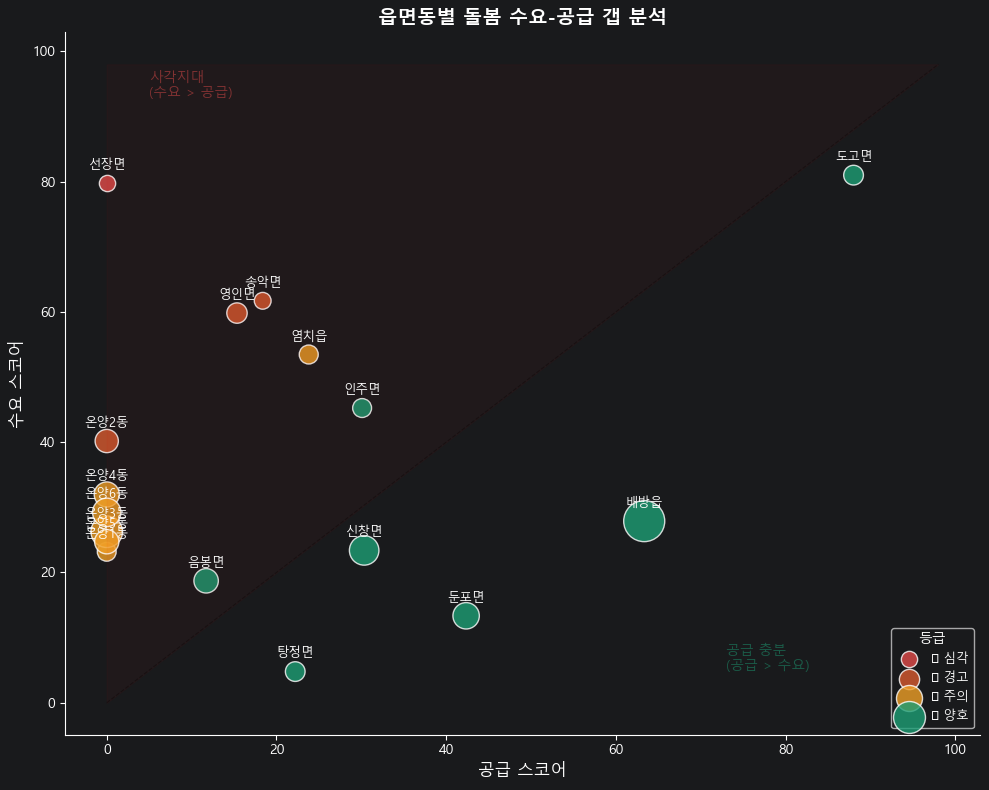

In [29]:
# ── 4-1. 수요 vs 공급 산점도 ──
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'🔴 심각': '#E24B4A', '🟠 경고': '#D85A30', '🟡 주의': '#EF9F27', '🟢 양호': '#1D9E75'}
for grade, color in colors.items():
    sub = gap[gap['등급'] == grade]
    ax.scatter(sub['공급_스코어'], sub['수요_스코어'], s=sub['고령인구']/10,
               c=color, alpha=0.8, edgecolors='white', linewidth=1, label=grade)

# 라벨
for _, row in gap.iterrows():
    ax.annotate(row['읍면동'], (row['공급_스코어'], row['수요_스코어']),
                fontsize=9, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

# 대각선 (수요=공급)
lim = max(gap['수요_스코어'].max(), gap['공급_스코어'].max()) + 10
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.3)
ax.fill_between([0, lim], [0, lim], [lim, lim], alpha=0.03, color='red')
ax.text(5, lim - 5, '사각지대\n(수요 > 공급)', fontsize=10, color='#E24B4A', alpha=0.5)
ax.text(lim - 25, 5, '공급 충분\n(공급 > 수요)', fontsize=10, color='#1D9E75', alpha=0.5)

ax.set_xlabel('공급 스코어', fontsize=12)
ax.set_ylabel('수요 스코어', fontsize=12)
ax.set_title('읍면동별 돌봄 수요-공급 갭 분석', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, title='등급')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(GAP_DIR / '4_1_수요공급_산점도.png', dpi=150, bbox_inches='tight')
plt.show()

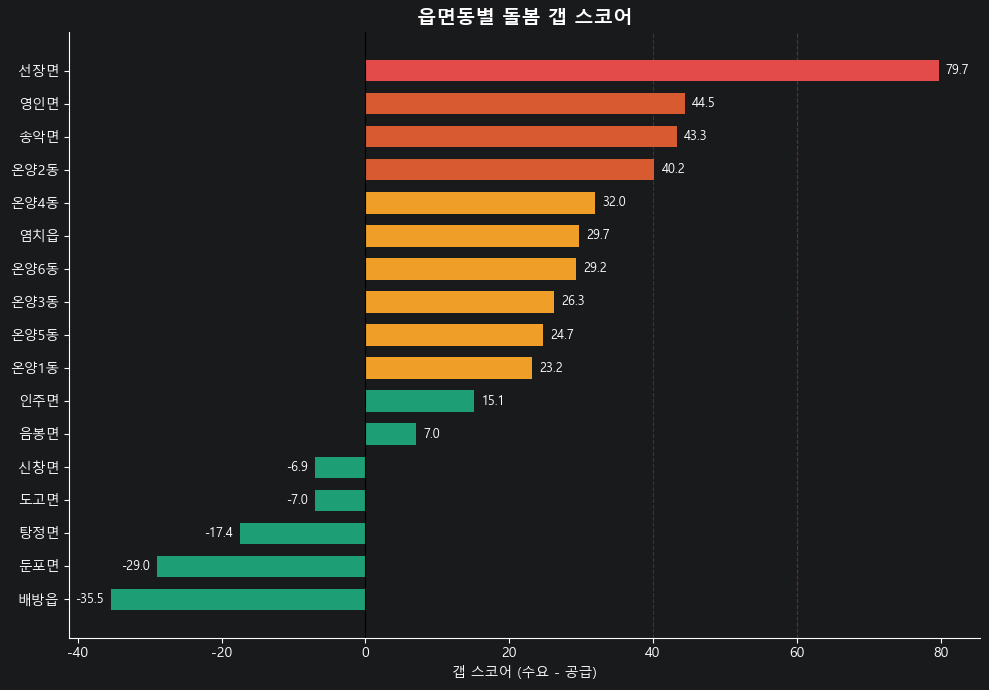

In [30]:
# ── 4-2. 갭 스코어 워터폴 차트 ──
df = gap.sort_values('갭_스코어', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = [colors.get(g, '#888') for g in df['등급']]
bars = ax.barh(df['읍면동'], df['갭_스코어'], color=bar_colors, height=0.65)

ax.axvline(x=0, color='black', lw=0.8)
ax.axvline(x=60, color='#E24B4A', ls='--', lw=0.8, alpha=0.4)
ax.axvline(x=40, color='#D85A30', ls='--', lw=0.8, alpha=0.3)

for bar, val in zip(bars, df['갭_스코어']):
    x_pos = bar.get_width() + 1 if val >= 0 else bar.get_width() - 1
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('갭 스코어 (수요 - 공급)')
ax.set_title('읍면동별 돌봄 갭 스코어', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(GAP_DIR / '4_2_갭스코어_바차트.png', dpi=150, bbox_inches='tight')
plt.show()

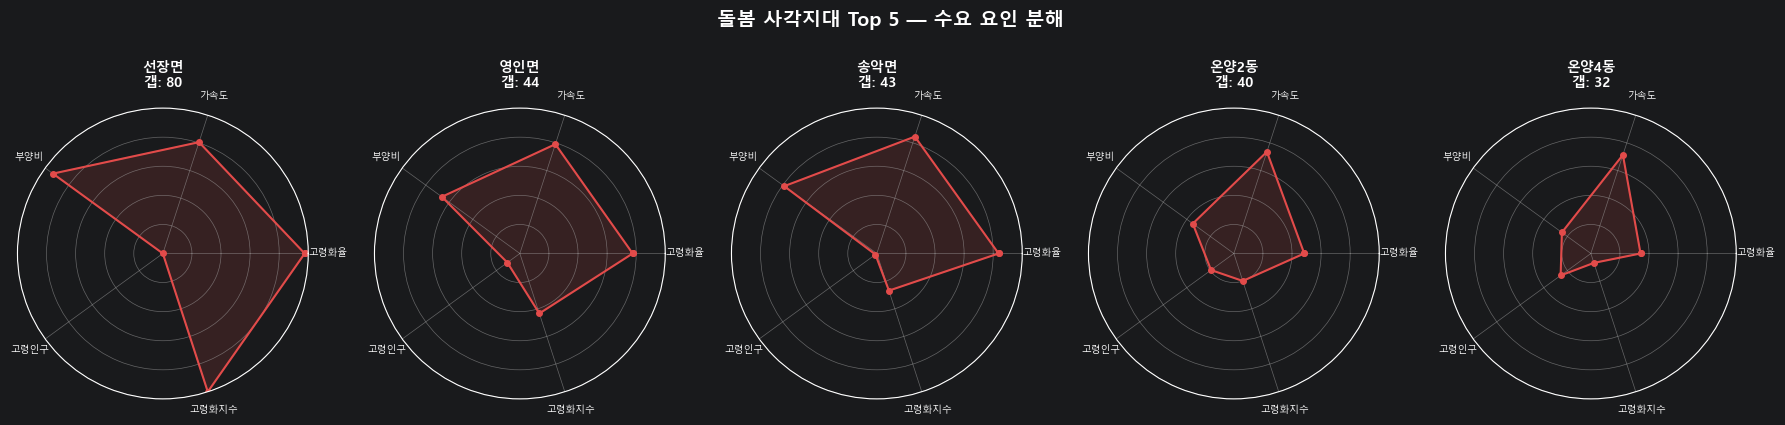

In [31]:
# ── 4-3. 수요/공급 구성 비교 (레이더 차트 - Top 5 사각지대) ──
from math import pi

top5 = gap.nlargest(5, '갭_스코어')
categories = ['고령화율', '가속도', '부양비', '고령인구', '고령화지수']

fig, axes = plt.subplots(1, 5, figsize=(18, 4), subplot_kw=dict(polar=True))

for idx, (_, row) in enumerate(top5.iterrows()):
    dong = row['읍면동']
    d = demand[demand['읍면동'] == dong].iloc[0]
    values = [d['n_고령화율'], d['n_가속도'], d['n_부양비'], d['n_고령인구'], d['n_고령화지수']]
    values += values[:1]  # 닫기

    angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]

    ax = axes[idx]
    ax.plot(angles, values, 'o-', lw=1.5, color='#E24B4A', markersize=4)
    ax.fill(angles, values, alpha=0.15, color='#E24B4A')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(f'{dong}\n갭: {row["갭_스코어"]:.0f}', fontsize=10, fontweight='bold', pad=15)
    ax.set_yticklabels([])

plt.suptitle('돌봄 사각지대 Top 5 — 수요 요인 분해', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(GAP_DIR / '4_3_사각지대_레이더.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. 사각지대별 부족 시설 유형 분석

In [32]:
# ── 아산시 전체 평균 유형별 비율 vs 사각지대 읍면동 ──
# 전체 유형별 비율
total_by_type = df_facility['종류'].value_counts()
total_ratio = (total_by_type / total_by_type.sum() * 100).round(1)

# 사각지대 Top 5 읍면동의 시설 구성
top5_dongs = gap.nlargest(5, '갭_스코어')['읍면동'].tolist()

print(f'아산시 전체 시설 유형 비율:')
print(total_ratio.to_string())
print(f'\n사각지대 Top 5: {top5_dongs}')

need_analysis = []
for dong in top5_dongs:
    dong_fac = df_facility[df_facility['읍면동'] == dong]
    existing = set(dong_fac['종류'].unique()) if len(dong_fac) > 0 else set()
    missing = set(total_by_type.index) - existing
    need_analysis.append({
        '읍면동': dong,
        '보유_시설수': len(dong_fac),
        '보유_유형': ', '.join(sorted(existing)) if existing else '없음',
        '미보유_유형': ', '.join(sorted(missing)) if missing else '전체 보유',
        '고령인구': ma_latest[ma_latest['읍면동'] == dong]['고령인구'].values[0]
    })

df_need = pd.DataFrame(need_analysis)
print('\n=== 사각지대 읍면동 시설 현황 ===')
df_need

아산시 전체 시설 유형 비율:
종류
방문요양         42.9
방문목욕         23.8
주야간보호        23.8
재가노인지원서비스     4.8
방문간호          3.6
복지용구          1.2

사각지대 Top 5: ['선장면', '영인면', '송악면', '온양2동', '온양4동']

=== 사각지대 읍면동 시설 현황 ===


,읍면동,보유_시설수,보유_유형,미보유_유형,고령인구
0,선장면,0,없음,"방문간호, 방문목욕, 방문요양, 복지용구, 재가노인지원서비스, 주야간보호",1375.0
1,영인면,1,주야간보호,"방문간호, 방문목욕, 방문요양, 복지용구, 재가노인지원서비스",2157.0
2,송악면,1,주야간보호,"방문간호, 방문목욕, 방문요양, 복지용구, 재가노인지원서비스",1464.0
3,온양2동,0,없음,"방문간호, 방문목욕, 방문요양, 복지용구, 재가노인지원서비스, 주야간보호",2802.0
4,온양4동,0,없음,"방문간호, 방문목욕, 방문요양, 복지용구, 재가노인지원서비스, 주야간보호",3266.0


---
## 6. 분석 결과 저장

In [34]:
# ── 저장 ──
gap_full = gap.sort_values('갭_순위')

gap_full.to_csv(GAP_DIR / 'gap_종합순위.csv', index=False, encoding='utf-8')
demand.to_csv(GAP_DIR / 'gap_수요스코어.csv', index=False, encoding='utf-8')
supply.to_csv(GAP_DIR / 'gap_공급스코어.csv', index=False, encoding='utf-8')
df_need.to_csv(GAP_DIR / 'gap_사각지대_시설현황.csv', index=False, encoding='utf-8')

print('✓ gap_종합순위.csv')
print('✓ gap_수요스코어.csv')
print('✓ gap_공급스코어.csv')
print('✓ gap_사각지대_시설현황.csv')
print(f'✓ 차트 3개 (.png)')
print(f'\n저장 경로: {GAP_DIR}')

✓ gap_종합순위.csv
✓ gap_수요스코어.csv
✓ gap_공급스코어.csv
✓ gap_사각지대_시설현황.csv
✓ 차트 3개 (.png)

저장 경로: C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\gap_analysis
